In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv('sales.csv')
df.head()

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales
0,20795,302,6,0.99,0,158101
1,5860,291,2,0.91,1,87796
2,43158,84,8,1.02,1,219061
3,49732,264,8,0.86,0,299134
4,16284,386,1,1.14,1,137693


In [3]:
feature_cols = ['Marketing_Spend', 'Store_Size', 'Competitor_Price_Index']
x = df[feature_cols]

In [ ]:
1, 3

In [4]:
x

,Marketing_Spend,Store_Size,Competitor_Price_Index
0,20795,302,0.99
1,5860,291,0.91
2,43158,84,1.02
3,49732,264,0.86
4,16284,386,1.14
...,...,...,...
495,48404,158,1.20
496,25491,195,1.10
497,43494,160,0.84
498,8373,277,0.92


In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
x_scaled

array([[-0.42935538,  0.25069994, -0.08971364],
       [-1.54374764,  0.16577972, -0.77065204],
       [ 1.23928568, -1.4322645 ,  0.16563827],
       ...,
       [ 1.26435671, -0.84554295, -1.36647315],
       [-1.35623725,  0.05769943, -0.68553474],
       [-0.70051048, -0.84554295, -1.36647315]])

In [ ]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(x_scaled)
    inertias.append(kmeans_temp.inertia_)

In [8]:
inertias

[1500.0,
 1112.2074849207236,
 899.4108724993291,
 712.2374831871917,
 585.7519524950307,
 492.28511279625275,
 425.603620181803,
 381.8849218637514,
 353.9821954442945,
 333.67401145251256]

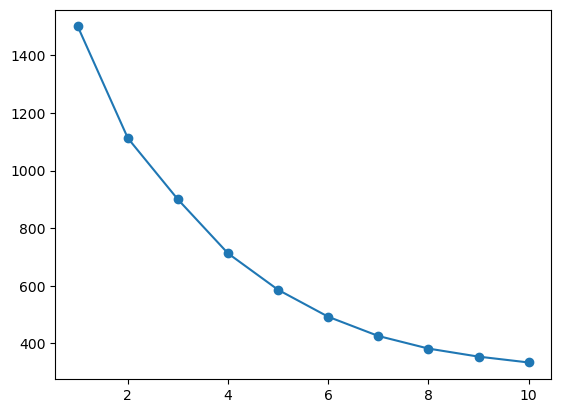

In [10]:
plt.plot(k_values, inertias, marker='o')

In [11]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(x_scaled)

c:\Users\learn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [12]:
df

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales,cluster
0,20795,302,6,0.99,0,158101,1
1,5860,291,2,0.91,1,87796,1
2,43158,84,8,1.02,1,219061,2
3,49732,264,8,0.86,0,299134,2
4,16284,386,1,1.14,1,137693,3
...,...,...,...,...,...,...,...
495,48404,158,7,1.20,1,253307,3
496,25491,195,8,1.10,0,163832,0
497,43494,160,6,0.84,0,268791,2
498,8373,277,6,0.92,0,87259,1


In [13]:
cluster_performance = (df.groupby('cluster')['Sales'].mean().sort_values())

In [14]:
cluster_performance

cluster
0     92655.353535
1    147042.129032
3    210868.582090
2    218216.153846
Name: Sales, dtype: float64

In [15]:
category_names = ['Low Value', 'Emerging', 'Core', 'High Value']

In [16]:
cluster_lables = {}
for i, cluster_id in enumerate(cluster_performance.index):
    cluster_lables[cluster_id] = category_names[i]

In [17]:
cluster_lables

{0: 'Low Value', 1: 'Emerging', 3: 'Core', 2: 'High Value'}

In [18]:
df['store_category'] = df['cluster'].map(cluster_lables)

In [19]:
df

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales,cluster,store_category
0,20795,302,6,0.99,0,158101,1,Emerging
1,5860,291,2,0.91,1,87796,1,Emerging
2,43158,84,8,1.02,1,219061,2,High Value
3,49732,264,8,0.86,0,299134,2,High Value
4,16284,386,1,1.14,1,137693,3,Core
...,...,...,...,...,...,...,...,...
495,48404,158,7,1.20,1,253307,3,Core
496,25491,195,8,1.10,0,163832,0,Low Value
497,43494,160,6,0.84,0,268791,2,High Value
498,8373,277,6,0.92,0,87259,1,Emerging


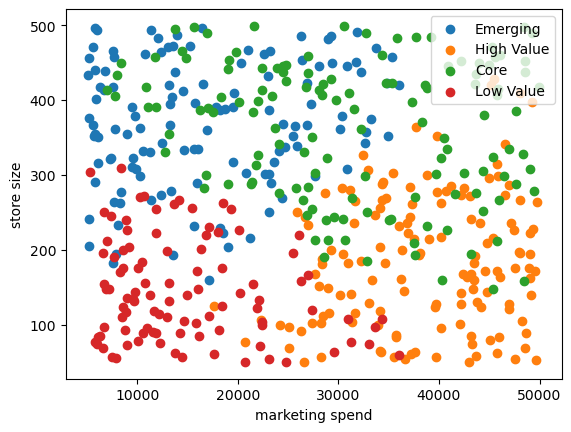

In [21]:
for category in df['store_category'].unique():
    data_cat = df[df['store_category']==category]
    plt.scatter(data_cat['Marketing_Spend'], data_cat['Store_Size'], label=category)
    plt.xlabel('marketing spend')
    plt.ylabel('store size')
    plt.legend()

In [23]:
joblib.dump(scaler, 'store_cluster_scaler.joblib')
joblib.dump(kmeans, 'store_kmeans_model.joblib')
joblib.dump(feature_cols, 'cluster_features.joblib')
joblib.dump(cluster_lables, 'cluster_labels.joblib')

['cluster_labels.joblib']